# 第一層：好球判定基準模型（GAM）

建模 **P(判好球 | 位置與情境)，不含捕手身分**——framing 的反事實基準。

模型（見 `models/baseline_gam.py`）：

$$\text{logit}\,P(\text{strike}) = \text{te}(plate\_x,\ plate\_z\_std) + f(stand) + f(p\_throws) + f(balls) + f(strikes)$$

- `te(...)`：位置的二維張量光滑面，捕捉好球帶形狀。
- `f(...)`：情境的 factor 加性項。
- 已剔除極端座標（|plate_x|≤2.5、標準化 z∈[-1,2]）避免邊界外插不穩。

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.calibration import calibration_curve

from models.baseline_gam import (
    load_modeling_frame, fit_or_load, fit_by_count, predict_grid, add_baseline_prob, FEATURES,
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Arial Unicode MS', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

df = load_modeling_frame(2023)
gam = fit_or_load(2023)   # 載入 models/artifacts 快取（不存在才重 fit）
X = df.select(FEATURES).to_numpy()
y = df['is_strike'].to_numpy()
print(f'{len(df):,} 顆判定球（剔除極端座標後）')

351,094 顆判定球（剔除極端座標後）


## 模型表現與校準

base rate : 0.3358


accuracy  : 0.9295
AUC       : 0.9808
log-loss  : 0.1674
Brier     : 0.0514


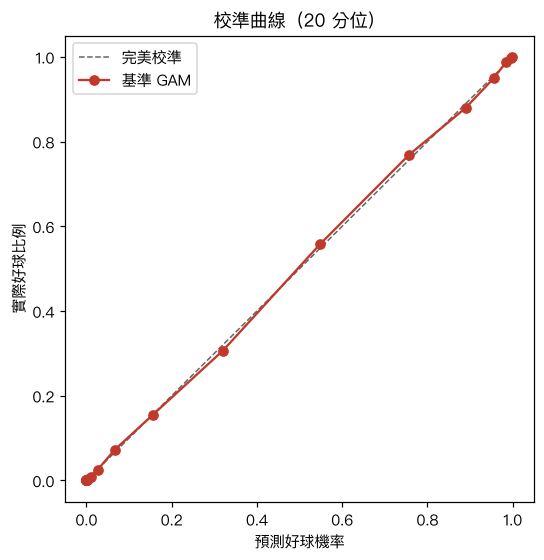

In [2]:
p = gam.predict_proba(X)
print(f'base rate : {y.mean():.4f}')
print(f'accuracy  : {gam.accuracy(X, y):.4f}')
print(f'AUC       : {roc_auc_score(y, p):.4f}')
print(f'log-loss  : {log_loss(y, p):.4f}')
print(f'Brier     : {brier_score_loss(y, p):.4f}')

frac_pos, mean_pred = calibration_curve(y, p, n_bins=20, strategy='quantile')
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='完美校準')
ax.plot(mean_pred, frac_pos, 'o-', color='#c0392b', label='基準 GAM')
ax.set_xlabel('預測好球機率'); ax.set_ylabel('實際好球比例')
ax.set_title('校準曲線（20 分位）'); ax.legend()
fig.savefig('../figures/gam_calibration_2023.png', bbox_inches='tight'); plt.show()

## 預測好球帶曲面 vs 實證

左：模型預測機率曲面（固定情境 R 打者/R 投手/0-0）與 **50% 等高線**（白線）。
右：EDA 的實證好球率熱圖。兩者形狀吻合即基準模型可信。

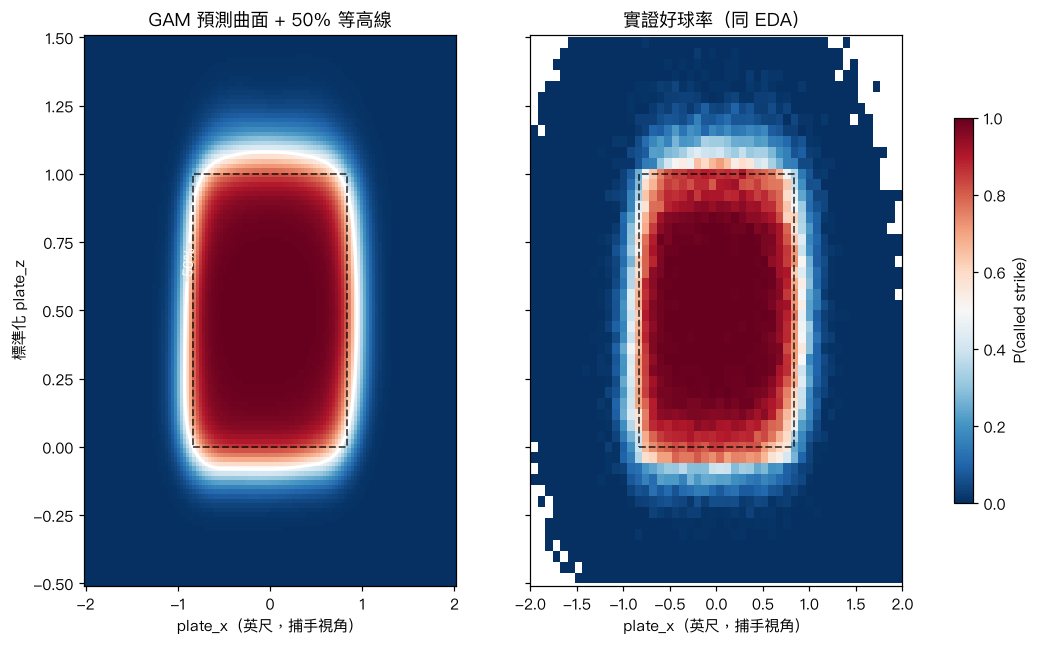

In [3]:
# 模型預測曲面
XX, ZZ, P = predict_grid(gam, context={'stand_i': 1, 'p_throws_i': 1, 'balls': 0, 'strikes': 0})

# 實證熱圖網格
def empirical_grid(data, x_range=(-2,2), z_range=(-0.5,1.5), bins=50, min_count=20):
    x=data['plate_x'].to_numpy(); z=data['plate_z_std'].to_numpy(); s=data['is_strike'].to_numpy()
    xe=np.linspace(*x_range,bins+1); ze=np.linspace(*z_range,bins+1)
    ssum,_,_=np.histogram2d(x,z,bins=[xe,ze],weights=s); tot,_,_=np.histogram2d(x,z,bins=[xe,ze])
    with np.errstate(invalid='ignore',divide='ignore'): rate=ssum/tot
    rate[tot<min_count]=np.nan; return rate,xe,ze
rate, xe, ze = empirical_grid(df)

fig, axes = plt.subplots(1, 2, figsize=(12, 6.5), sharey=True)
m0 = axes[0].pcolormesh(XX, ZZ, P, cmap='RdBu_r', vmin=0, vmax=1)
cs = axes[0].contour(XX, ZZ, P, levels=[0.5], colors='white', linewidths=2)
axes[0].clabel(cs, fmt='50%%', fontsize=9)
axes[0].set_title('GAM 預測曲面 + 50% 等高線')
m1 = axes[1].pcolormesh(xe, ze, rate.T, cmap='RdBu_r', vmin=0, vmax=1)
axes[1].set_title('實證好球率（同 EDA）')
for ax in axes:
    ax.plot([-0.83,0.83,0.83,-0.83,-0.83],[0,0,1,1,0],'k--',lw=1.2,alpha=0.7)
    ax.set_xlabel('plate_x（英尺，捕手視角）')
axes[0].set_ylabel('標準化 plate_z')
fig.colorbar(m1, ax=axes, label='P(called strike)', shrink=0.7)
fig.savefig('../figures/gam_surface_vs_empirical_2023.png', bbox_inches='tight'); plt.show()

## 球數如何改變好球帶：50% 等高線分面

重現「球數影響好球帶」的著名現象。這裡對 **0-2 / 1-1 / 3-0** 各自 fit 一個獨立的位置
光滑面（`fit_by_count`），畫其 50% 等機率線疊圖——**允許好球帶的形狀隨球數改變**，
而不只是整體高低平移。

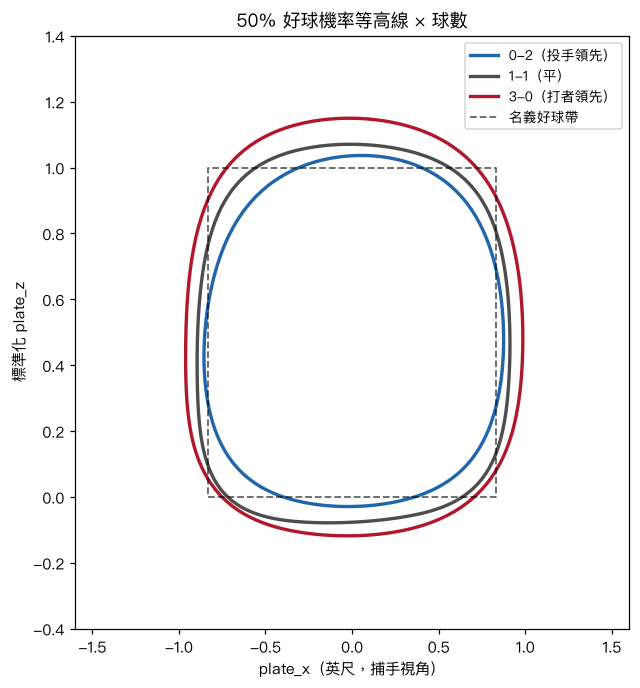

In [4]:
counts = [(0,2),(1,1),(3,0)]
labels = {(0,2):'0-2（投手領先）',(1,1):'1-1（平）',(3,0):'3-0（打者領先）'}
colors = {(0,2):'#2166ac',(1,1):'#4d4d4d',(3,0):'#b2182b'}
count_gams = fit_by_count(df, counts)

fig, ax = plt.subplots(figsize=(6.5, 7))
for c in counts:
    GX, GZ, GP = predict_grid(count_gams[c], tensor_only=True)
    cs = ax.contour(GX, GZ, GP, levels=[0.5], colors=[colors[c]], linewidths=2.2)
    ax.plot([], [], color=colors[c], lw=2.2, label=labels[c])
ax.plot([-0.83,0.83,0.83,-0.83,-0.83],[0,0,1,1,0],'k--',lw=1.2,alpha=0.6,label='名義好球帶')
ax.set_xlabel('plate_x（英尺，捕手視角）'); ax.set_ylabel('標準化 plate_z')
ax.set_title('50% 好球機率等高線 × 球數'); ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-1.6,1.6); ax.set_ylim(-0.4,1.4)
fig.savefig('../figures/gam_count_contours_2023.png', bbox_inches='tight'); plt.show()

## 輸出基準機率（供第二層）

把每顆球的基準好球機率加回資料存檔，供週 5 的 framing runs：
`framing 貢獻 = (實際判定 − 基準機率)`，按捕手加總。

In [5]:
out = add_baseline_prob(df, gam)
out_path = '../data/processed/statcast_2023_baseline.parquet'
out.write_parquet(out_path)
print('已存', out_path, '欄位 baseline_strike_prob')
print(out.select(['plate_x','plate_z_std','balls','strikes','is_strike','baseline_strike_prob']).head())

已存 ../data/processed/statcast_2023_baseline.parquet 欄位 baseline_strike_prob
shape: (5, 6)
┌───────────┬─────────────┬───────┬─────────┬───────────┬──────────────────────┐
│ plate_x   ┆ plate_z_std ┆ balls ┆ strikes ┆ is_strike ┆ baseline_strike_prob │
│ ---       ┆ ---         ┆ ---   ┆ ---     ┆ ---       ┆ ---                  │
│ f64       ┆ f64         ┆ i64   ┆ i64     ┆ i8        ┆ f64                  │
╞═══════════╪═════════════╪═══════╪═════════╪═══════════╪══════════════════════╡
│ 0.017651  ┆ 0.468232    ┆ 0     ┆ 0       ┆ 1         ┆ 0.999765             │
│ -0.577526 ┆ -0.188462   ┆ 0     ┆ 0       ┆ 1         ┆ 0.058218             │
│ 2.212413  ┆ -0.262088   ┆ 0     ┆ 0       ┆ 0         ┆ 3.8681e-10           │
│ 1.402476  ┆ -0.764658   ┆ 1     ┆ 1       ┆ 0         ┆ 1.9973e-9            │
│ 1.187945  ┆ 0.696818    ┆ 0     ┆ 1       ┆ 0         ┆ 0.013327             │
└───────────┴─────────────┴───────┴─────────┴───────────┴──────────────────────┘


## 觀察

- 基準 GAM 判別力強（AUC ≈ 0.98）且校準良好，預測曲面與實證熱圖形狀一致——可作為 framing 的可信基準。
- **球數等高線**：0-2 的好球帶明顯內縮、3-0 明顯外擴，重現球數效應；且各球數獨立 fit 允許**形狀**改變（不只上下平移）。
- 主力基準模型的球數項是**加性**的（只平移不變形）——這是計算取捨。位置×球數的真實交互，短期用上面的分面診斷呈現，長期可在階層模型或加交互項時納入。
- 已輸出每球 `baseline_strike_prob` → 下一步（週 5）簡單版 framing runs 與官方榜單對照。